In [4]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

nih_csv = r"C:\Projet ML\DATA\NIH\Data_Entry_2017.csv"
train_val_list_path = r"C:\Projet ML\DATA\NIH\train_val_list.txt"
test_list_path = r"C:\Projet ML\DATA\NIH\test_list.txt"
nih_root = r"C:\Projet ML\DATA\NIH"

df = pd.read_csv(nih_csv)

with open(train_val_list_path, "r", encoding="utf-8") as f:
    train_val_images = set(line.strip() for line in f if line.strip().endswith(".png"))

with open(test_list_path, "r", encoding="utf-8") as f:
    test_images = set(line.strip() for line in f if line.strip().endswith(".png"))

image_paths = {}
for i in range(1, 13):
    folder = os.path.join(nih_root, f"images_{i:03d}", "images")
    for img_path in glob.glob(os.path.join(folder, "*.png")):
        image_name = os.path.basename(img_path)
        image_paths[image_name] = img_path

print("Nombre d'images trouvées :", len(image_paths))

df["image_path"] = df["Image Index"].map(image_paths)

df = df[df["image_path"].notna()].copy()

valid_images = train_val_images.union(test_images)
df = df[df["Image Index"].isin(valid_images)].copy()

df["split"] = "other"
df.loc[df["Image Index"].isin(train_val_images), "split"] = "train_val"
df.loc[df["Image Index"].isin(test_images), "split"] = "test"

print(df["split"].value_counts())

all_labels = sorted(set(
    label
    for row in df["Finding Labels"]
    for label in row.split("|")
))

if "No Finding" in all_labels:
    all_labels.remove("No Finding")

for label in all_labels:
    df[label] = df["Finding Labels"].apply(lambda x: int(label in x.split("|")))

print("Labels :", all_labels)

train_val_df = df[df["split"] == "train_val"].copy()
test_df = df[df["split"] == "test"].copy()

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    random_state=42
)

print("train :", train_df.shape)
print("val   :", val_df.shape)
print("test  :", test_df.shape)

print(train_df[[
    "Image Index",
    "image_path",
    "Finding Labels",
    "Patient Age",
    "Patient Gender",
    "View Position"
]].head())

Nombre d'images trouvées : 112120
split
train_val    86524
test         25596
Name: count, dtype: int64
Labels : ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
train : (69219, 28)
val   : (17305, 28)
test  : (25596, 28)
            Image Index                                         image_path  \
78652  00019292_002.png  C:\Projet ML\DATA\NIH\images_009\images\000192...   
6492   00001739_000.png  C:\Projet ML\DATA\NIH\images_002\images\000017...   
80182  00019707_001.png  C:\Projet ML\DATA\NIH\images_009\images\000197...   
16994  00004552_000.png  C:\Projet ML\DATA\NIH\images_003\images\000045...   
56414  00014032_004.png  C:\Projet ML\DATA\NIH\images_007\images\000140...   

      Finding Labels  Patient Age Patient Gender View Position  
78652     No Finding           22              M            AP  
6492      No Finding           57     

In [5]:
import pandas as pd
import numpy as np

def prepare_metadata(dataframe, reference_columns=None):
    meta = dataframe[["Patient Age", "Patient Gender", "View Position"]].copy()

    meta["Patient Age"] = (
        meta["Patient Age"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
    )

    meta["Patient Gender"] = meta["Patient Gender"].map({"M": 0, "F": 1})

    meta = pd.get_dummies(meta, columns=["View Position"], dummy_na=True)

    if reference_columns is not None:
        meta = meta.reindex(columns=reference_columns, fill_value=0)

    return meta

X_train_meta = prepare_metadata(train_df)
X_val_meta = prepare_metadata(val_df, reference_columns=X_train_meta.columns)
X_test_meta = prepare_metadata(test_df, reference_columns=X_train_meta.columns)

print(X_train_meta.shape, X_val_meta.shape, X_test_meta.shape)
print(X_train_meta.head())

(69219, 5) (17305, 5) (25596, 5)
       Patient Age  Patient Gender  View Position_AP  View Position_PA  \
78652         22.0               0              True             False   
6492          57.0               1             False              True   
80182         58.0               0             False              True   
16994         56.0               0             False              True   
56414         61.0               0             False              True   

       View Position_nan  
78652              False  
6492               False  
80182              False  
16994              False  
56414              False  


In [6]:
y_train = train_df[all_labels].values.astype("float32")
y_val = val_df[all_labels].values.astype("float32")
y_test = test_df[all_labels].values.astype("float32")

print(y_train.shape, y_val.shape, y_test.shape)

(69219, 14) (17305, 14) (25596, 14)


In [7]:
from PIL import Image

def preprocess_image(image_path, target_size=(128, 128)):
    image = Image.open(image_path).convert("L")
    image = image.resize(target_size)
    arr = np.array(image).astype("float32") / 255.0
    arr = np.expand_dims(arr, axis=-1)
    return arr

X_train_img = np.array([preprocess_image(p) for p in train_df["image_path"]], dtype="float32")
X_val_img = np.array([preprocess_image(p) for p in val_df["image_path"]], dtype="float32")
X_test_img = np.array([preprocess_image(p) for p in test_df["image_path"]], dtype="float32")

print(X_train_img.shape, X_val_img.shape, X_test_img.shape)

(69219, 128, 128, 1) (17305, 128, 128, 1) (25596, 128, 128, 1)


In [8]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

meta_model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
meta_model.fit(X_train_meta, y_train)

meta_probs_val = meta_model.predict_proba(X_val_meta)
meta_probs_test = meta_model.predict_proba(X_test_meta)

print(meta_probs_test.shape)

(25596, 14)


In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

image_model = keras.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(all_labels), activation="sigmoid")
])

image_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[keras.metrics.BinaryAccuracy(name="binary_accuracy")]
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_img = image_model.fit(
    X_train_img,
    y_train,
    validation_data=(X_val_img, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 319s 146ms/step - binary_accuracy: 0.9553 - loss: 0.1599 - val_binary_accuracy: 0.9547 - val_loss: 0.1579
Epoch 2/10
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 307s 142ms/step - binary_accuracy: 0.9556 - loss: 0.1545 - val_binary_accuracy: 0.9548 - val_loss: 0.1556
Epoch 3/10
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 302s 139ms/step - binary_accuracy: 0.9557 - loss: 0.1516 - val_binary_accuracy: 0.9548 - val_loss: 0.1543
Epoch 4/10
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 309s 143ms/step - binary_accuracy: 0.9557 - loss: 0.1488 - val_binary_accuracy: 0.9548 - val_loss: 0.1527
Epoch 5/10
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 307s 142ms/step - binary_accuracy: 0.9559 - loss: 0.1458 - val_binary_accuracy: 0.9549 - val_loss: 0.1524
Epoch 6/10
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 307s 142ms/step - binary_accuracy: 0.9561 - loss: 0.1426 - val_binary_accuracy: 0.9549 - val_loss: 0.1530
Epoch 7/10
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 306s 141ms/step - binary_accuracy: 0.9563 - loss: 0.1390 - val_binary_

In [10]:
image_probs_val = image_model.predict(X_val_img, verbose=0)
image_probs_test = image_model.predict(X_test_img, verbose=0)

print(image_probs_test.shape)

(25596, 14)


In [11]:
alpha = 0.8 
beta = 0.2   

fusion_probs_val = alpha * image_probs_val + beta * meta_probs_val
fusion_probs_test = alpha * image_probs_test + beta * meta_probs_test

In [12]:
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score

def evaluate_multilabel(y_true, y_probs, threshold=0.5):
    y_pred = (y_probs >= threshold).astype(int)

    results = {
        "roc_auc_macro": roc_auc_score(y_true, y_probs, average="macro"),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "ap_macro": average_precision_score(y_true, y_probs, average="macro"),
    }
    return results

metrics_meta = evaluate_multilabel(y_test, meta_probs_test, threshold=0.5)
metrics_image = evaluate_multilabel(y_test, image_probs_test, threshold=0.5)
metrics_fusion = evaluate_multilabel(y_test, fusion_probs_test, threshold=0.5)

print("Métadonnées seules :", metrics_meta)
print("Image seule        :", metrics_image)
print("Fusion             :", metrics_fusion)

Métadonnées seules : {'roc_auc_macro': 0.6018024870040051, 'f1_macro': 0.00015530665482196008, 'ap_macro': 0.09834509448133597}
Image seule        : {'roc_auc_macro': 0.667916447578193, 'f1_macro': 0.011816803281142355, 'ap_macro': 0.13755232128758713}
Fusion             : {'roc_auc_macro': 0.6733221143671296, 'f1_macro': 0.004747518501343255, 'ap_macro': 0.13832807746456896}


In [13]:
thresholds = [0.2, 0.3, 0.4, 0.5]

for t in thresholds:
    print(f"\n=== Threshold = {t} ===")
    print("Métadonnées :", evaluate_multilabel(y_test, meta_probs_test, threshold=t))
    print("Image       :", evaluate_multilabel(y_test, image_probs_test, threshold=t))
    print("Fusion      :", evaluate_multilabel(y_test, fusion_probs_test, threshold=t))


=== Threshold = 0.2 ===
Métadonnées : {'roc_auc_macro': 0.6018024870040051, 'f1_macro': 0.026741556876010063, 'ap_macro': 0.09834509448133597}
Image       : {'roc_auc_macro': 0.667916447578193, 'f1_macro': 0.10793388331155333, 'ap_macro': 0.13755232128758713}
Fusion      : {'roc_auc_macro': 0.6733221143671296, 'f1_macro': 0.09410148261830566, 'ap_macro': 0.13832807746456896}

=== Threshold = 0.3 ===
Métadonnées : {'roc_auc_macro': 0.6018024870040051, 'f1_macro': 0.00023689268729320097, 'ap_macro': 0.09834509448133597}
Image       : {'roc_auc_macro': 0.667916447578193, 'f1_macro': 0.06480346560770019, 'ap_macro': 0.13755232128758713}
Fusion      : {'roc_auc_macro': 0.6733221143671296, 'f1_macro': 0.04992356147960246, 'ap_macro': 0.13832807746456896}

=== Threshold = 0.4 ===
Métadonnées : {'roc_auc_macro': 0.6018024870040051, 'f1_macro': 0.00023689268729320097, 'ap_macro': 0.09834509448133597}
Image       : {'roc_auc_macro': 0.667916447578193, 'f1_macro': 0.030753449634281668, 'ap_macro

In [15]:
best_result = None

weights_to_test = [
    (0.9, 0.1),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
]

for alpha, beta in weights_to_test:
    fusion_val = alpha * image_probs_val + beta * meta_probs_val
    scores = evaluate_multilabel(y_val, fusion_val, threshold=0.3)

    result = {
        "alpha": alpha,
        "beta": beta,
        **scores
    }

    print(result)

    if best_result is None or result["roc_auc_macro"] > best_result["roc_auc_macro"]:
        best_result = result

print("\nMeilleure pondération :", best_result)

{'alpha': 0.9, 'beta': 0.1, 'roc_auc_macro': 0.7269369344091788, 'f1_macro': 0.044223529932039166, 'ap_macro': 0.11730015432589903}
{'alpha': 0.8, 'beta': 0.2, 'roc_auc_macro': 0.7286802355580791, 'f1_macro': 0.038129080576745834, 'ap_macro': 0.11742137277096464}
{'alpha': 0.7, 'beta': 0.3, 'roc_auc_macro': 0.7295925589144411, 'f1_macro': 0.030380971463754677, 'ap_macro': 0.11734069831971561}
{'alpha': 0.6, 'beta': 0.4, 'roc_auc_macro': 0.7293715206139337, 'f1_macro': 0.022204605786005138, 'ap_macro': 0.11694154381801707}

Meilleure pondération : {'alpha': 0.7, 'beta': 0.3, 'roc_auc_macro': 0.7295925589144411, 'f1_macro': 0.030380971463754677, 'ap_macro': 0.11734069831971561}


In [16]:
best_alpha = best_result["alpha"]
best_beta = best_result["beta"]

fusion_probs_test = best_alpha * image_probs_test + best_beta * meta_probs_test
final_metrics_fusion = evaluate_multilabel(y_test, fusion_probs_test, threshold=0.3)

print(final_metrics_fusion)

{'roc_auc_macro': 0.6752574160275827, 'f1_macro': 0.03949701968855491, 'ap_macro': 0.13868439311261352}


In [17]:
results_df = pd.DataFrame([
    {"Model": "Metadata only", **metrics_meta},
    {"Model": "Image only", **metrics_image},
    {"Model": "Image + metadata fusion", **metrics_fusion},
])

print(results_df)

                     Model  roc_auc_macro  f1_macro  ap_macro
0            Metadata only       0.601802  0.000155  0.098345
1               Image only       0.667916  0.011817  0.137552
2  Image + metadata fusion       0.673322  0.004748  0.138328


In [18]:
def get_top_labels(probs, labels, threshold=0.3):
    output = []
    for i, p in enumerate(probs):
        if p >= threshold:
            output.append((labels[i], float(p)))
    output.sort(key=lambda x: x[1], reverse=True)
    return output

idx = 0

print("Image :", test_df.iloc[idx]["Image Index"])
print("Labels réels :")
print([label for label in all_labels if test_df.iloc[idx][label] == 1])

print("\nPrédictions image seule :")
print(get_top_labels(image_probs_test[idx], all_labels, threshold=0.3))

print("\nPrédictions métadonnées seules :")
print(get_top_labels(meta_probs_test[idx], all_labels, threshold=0.3))

print("\nPrédictions fusion :")
print(get_top_labels(fusion_probs_test[idx], all_labels, threshold=0.3))

Image : 00000003_000.png
Labels réels :
['Hernia']

Prédictions image seule :
[]

Prédictions métadonnées seules :
[]

Prédictions fusion :
[]


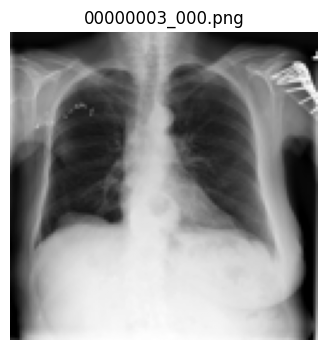

In [19]:
import matplotlib.pyplot as plt

def show_test_example(idx):
    img = X_test_img[idx].squeeze()
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap="gray")
    plt.title(test_df.iloc[idx]["Image Index"])
    plt.axis("off")
    plt.show()

show_test_example(0)

In [22]:
import mlflow
import mlflow.keras

with mlflow.start_run(run_name="nih_image_metadata_fusion"):
    mlflow.log_param("image_size", 128)
    mlflow.log_param("fusion_type", "late_fusion")
    mlflow.log_param("alpha", best_alpha)
    mlflow.log_param("beta", best_beta)
    mlflow.log_param("metadata_features", list(X_train_meta.columns))
    mlflow.log_param("threshold", 0.3)

    mlflow.log_metric("metadata_roc_auc_macro", metrics_meta["roc_auc_macro"])
    mlflow.log_metric("metadata_f1_macro", metrics_meta["f1_macro"])
    mlflow.log_metric("image_roc_auc_macro", metrics_image["roc_auc_macro"])
    mlflow.log_metric("image_f1_macro", metrics_image["f1_macro"])
    mlflow.log_metric("fusion_roc_auc_macro", final_metrics_fusion["roc_auc_macro"])
    mlflow.log_metric("fusion_f1_macro", final_metrics_fusion["f1_macro"])
    mlflow.log_metric("fusion_ap_macro", final_metrics_fusion["ap_macro"])

    results_df.to_csv("multimodal_results.csv", index=False)
    mlflow.log_artifact("multimodal_results.csv")

    image_model.save("nih_image_model.keras")
    mlflow.keras.log_model(image_model, "image_model")

c:\Users\dimit\Documents\Cours_M1\deep_learning_machine_learning\tfenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/03/29 17:50:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/29 17:50:29 INFO mlflow.store.db.utils: Updating database tables
2026/03/29 17:50:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/29 17:50:31 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
